# Análise Exploratória de Dados
## Imóveis Grande Florianópolis

**Etapas:**
- 0. Carregamento e tipos
- 1. Estatística descritiva geral
- 1b. Estatísticas por tipo e região
- 2. Distribuição do alvo: valor e log(valor) + Shapiro-França + QQ-plot
- 3. Distribuições das variáveis numéricas
- 4. Preço/m² por região
- 5. Correlação de Spearman e Point-Biserial
- 6. Boxplots por grupo + Kruskal-Wallis
- 6b. Análise comparativa por tipo e região
- 7. Impacto das amenidades
- 8. Matriz de correlação
- 9. VIF

---
## Imports e configurações

In [85]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, kruskal, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')


plt.rcParams.update({
    # Fonte
    'font.family':          'Arial',
    'font.size':            10,
    'axes.labelsize':       11,
    'axes.labelcolor':      'black',

    # Título — nunca usar, mas garante que não apareça se chamado por engano
    'axes.titlesize':       0,

    # Bordas (spines): só esquerda e inferior, pretas, 1.5pt
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.spines.left':     True,
    'axes.spines.bottom':   True,
    'axes.linewidth':       1.5,
    'axes.edgecolor':       'black',

    # Ticks
    'xtick.color':          'black',
    'ytick.color':          'black',
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,

    # Grid e fundo
    'axes.grid':            False,
    'axes.facecolor':       'white',
    'figure.facecolor':     'white',

    # DPI
    'figure.dpi':           120,
})

COR = '#4878CF'
print('Estilo configurado.')

Estilo configurado.


## Configurações de caminho

In [45]:
ENTRADA   = 'imoveis_sanitizado.csv'
SAIDA_DIR = 'eda_output'
os.makedirs(SAIDA_DIR, exist_ok=True)

NUMERICAS   = ['tamanho_m2', 'quartos', 'banheiros', 'vagas', 'valor']
AMENIDADES  = ['piscina', 'sacada', 'churrasqueira', 'imovel_mobiliado',
               'elevador', 'academia', 'salao_de_festas']
CATEGORICAS = ['regiao', 'tipo']
print(f'Saída em: {os.path.abspath(SAIDA_DIR)}')

Saída em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\eda_output


---
## Etapa 0 — Carregamento

In [46]:
df = pd.read_csv(ENTRADA, encoding='utf-8-sig', low_memory=False)
df[NUMERICAS]   = df[NUMERICAS].apply(pd.to_numeric, errors='coerce')
df[AMENIDADES]  = df[AMENIDADES].fillna(0).astype(int)
df[CATEGORICAS] = df[CATEGORICAS].astype('category')
df['log_valor']     = np.log(df['valor'])
df['preco_m2']      = df['valor'] / df['tamanho_m2']
df['m2_por_quarto'] = df['tamanho_m2'] / df['quartos']
print(f'{len(df):,} observações carregadas.')
df.head()

8,057 observações carregadas.


,imobiliaria,tipo,rua,bairro,cidade,tamanho_m2,quartos,banheiros,vagas,valor,...,piscina,sacada,churrasqueira,imovel_mobiliado,elevador,academia,salao_de_festas,log_valor,preco_m2,m2_por_quarto
0,Crédito Real,Casa,Servidão José Firmino Mangrich,Boa Vista,Biguaçu,44.0,1.0,1.0,0,90000.0,...,0,0,0,0,0,0,0,11.407565,2045.454545,44.000000
1,Crédito Real,Casa,Rua Antônio Mariano Filho,Área Rural de Biguaçu,Biguaçu,619.0,2.0,1.0,2,408100.0,...,0,1,0,0,0,0,0,12.919268,659.289176,309.500000
2,Crédito Real,Casa,Travessa Maria Salomé Ventura,Tijuquinhas,Biguaçu,86.0,3.0,2.0,5,375000.0,...,1,1,0,1,0,0,0,12.834681,4360.465116,28.666667
3,Crédito Real,Casa,Servidão Hermann Vieira,Centro,Biguaçu,177.0,3.0,2.0,2,900000.0,...,1,0,0,0,0,0,0,13.710150,5084.745763,59.000000
4,Crédito Real,Apartamento,Rua Domingos Coelho,Praia João Rosa,Biguaçu,48.0,2.0,1.0,1,282000.0,...,1,0,0,0,1,0,1,12.549662,5875.000000,24.000000


---
## Etapa 1 — Estatística descritiva geral

In [47]:
desc = df[NUMERICAS + ['preco_m2']].describe().T
desc['skewness'] = df[NUMERICAS + ['preco_m2']].skew()
desc['kurtosis'] = df[NUMERICAS + ['preco_m2']].kurt()
desc = desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']].round(2)
desc.to_csv(os.path.join(SAIDA_DIR, 'descritiva_geral.csv'), encoding='utf-8-sig')
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
tamanho_m2,8057.0,143.05,111.27,11.0,71.00,106.00,176.00,1000.00,2.34,8.03
quartos,8057.0,2.73,1.09,1.0,2.00,3.00,3.00,9.00,1.11,3.17
banheiros,8057.0,2.54,1.37,1.0,2.00,2.00,3.00,12.00,1.18,2.24
vagas,8057.0,1.68,1.19,0.0,1.00,1.00,2.00,12.00,1.75,6.36
valor,8057.0,1655513.25,1956595.82,90000.0,680000.00,1100000.00,1850000.00,50000000.00,6.58,93.73
preco_m2,8057.0,11894.56,7095.22,490.2,7128.57,10327.59,14835.16,138183.31,3.16,29.64


In [48]:
for col in CATEGORICAS:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())


regiao:
regiao
Central        2051
Norte          1273
São José       1168
Palhoça         964
Sul             922
Continental     758
Leste           724
Biguaçu         197

tipo:
tipo
Apartamento    4914
Casa           3142


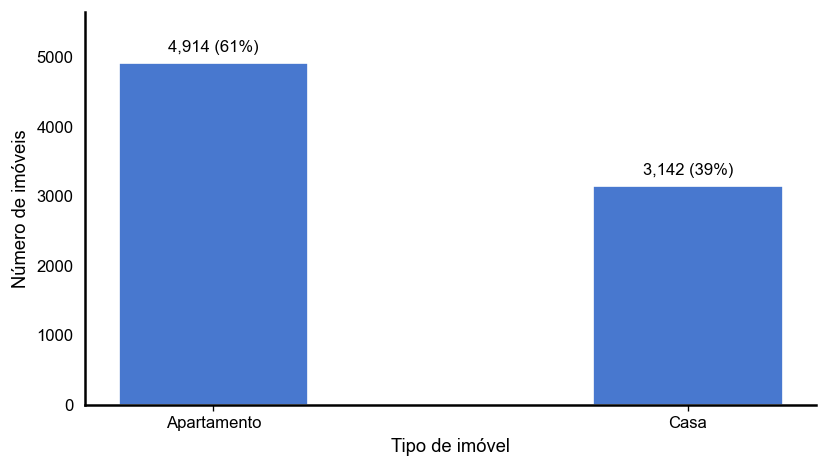

In [90]:
# Contagem por tipo de imóvel
contagem_tipo = df['tipo'].value_counts().reset_index()
contagem_tipo.columns = ['tipo', 'n']
contagem_tipo['pct'] = 100 * contagem_tipo['n'] / len(df)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contagem_tipo['tipo'], contagem_tipo['n'],
              color=COR, edgecolor='white', width=0.4)
ax.bar_label(bars,
             labels=[f"{row['n']:,} ({row['pct']:.0f}%)"
                     for _, row in contagem_tipo.iterrows()],
             padding=5, fontsize=10)
ax.set_xlabel('Tipo de imóvel')
ax.set_ylabel('Número de imóveis')
ax.set_ylim(0, contagem_tipo['n'].max() * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'contagem_por_tipo.png'), bbox_inches='tight', dpi=150)
plt.show()

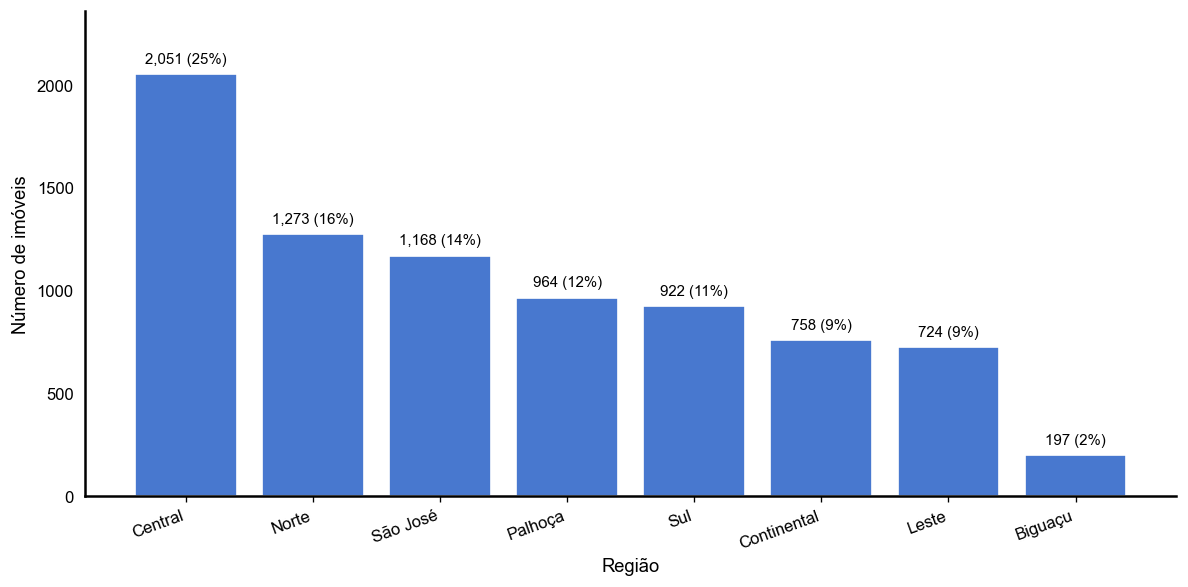

In [92]:
# Contagem por região
contagem_regiao = (df.groupby('regiao', observed=True)
                     .size()
                     .reset_index(name='n')
                     .sort_values('n', ascending=False))
contagem_regiao['pct'] = 100 * contagem_regiao['n'] / len(df)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(contagem_regiao['regiao'], contagem_regiao['n'],
              color=COR, edgecolor='white')
ax.bar_label(bars,
             labels=[f"{row['n']:,} ({row['pct']:.0f}%)"
                     for _, row in contagem_regiao.iterrows()],
             padding=5, fontsize=9)
ax.set_xlabel('Região')
ax.set_ylabel('Número de imóveis')
ax.set_ylim(0, contagem_regiao['n'].max() * 1.15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'contagem_por_regiao.png'), bbox_inches='tight', dpi=150)
plt.show()

In [49]:
print(f"{'Amenidade':<25} {'N':>6}  {'%':>6}")
print('-' * 42)
for am, n in df[AMENIDADES].sum().sort_values(ascending=False).items():
    print(f'{am:<25} {n:>6}  ({100*n/len(df):.1f}%)')

Amenidade                      N       %
------------------------------------------
churrasqueira               5623  (69.8%)
salao_de_festas             3214  (39.9%)
piscina                     3201  (39.7%)
elevador                    3174  (39.4%)
sacada                      2872  (35.6%)
imovel_mobiliado            2439  (30.3%)
academia                     910  (11.3%)


---
## Etapa 1b — Estatísticas por tipo e por região

In [50]:
vars_desc = ['tamanho_m2', 'quartos', 'banheiros', 'vagas', 'valor', 'preco_m2']
print('=== Por tipo de imóvel ===\n')
for var in vars_desc:
    print(f'{var}:')
    print(df.groupby('tipo', observed=True)[var]
            .agg(média='mean', mediana='median', desvio='std', n='count').round(2))
    print()

=== Por tipo de imóvel ===

tamanho_m2:
              média  mediana  desvio     n
tipo                                      
Apartamento  100.86     83.0   65.47  4914
Casa         209.04    174.0  133.82  3142

quartos:
             média  mediana  desvio     n
tipo                                     
Apartamento   2.34      2.0    0.83  4914
Casa          3.34      3.0    1.17  3142

banheiros:
             média  mediana  desvio     n
tipo                                     
Apartamento   2.18      2.0    1.14  4914
Casa          3.12      3.0    1.49  3142

vagas:
             média  mediana  desvio     n
tipo                                     
Apartamento   1.34      1.0    0.77  4914
Casa          2.20      2.0    1.51  3142

valor:
                  média    mediana      desvio     n
tipo                                                
Apartamento  1462936.41   971256.5  1688419.08  4914
Casa         1956715.70  1365000.0  2282740.32  3142

preco_m2:
                média  

In [51]:
print('=== Valor mediano por região ===\n')
print(df.groupby('regiao', observed=True)[['valor','preco_m2','tamanho_m2']]
        .median().sort_values('valor', ascending=False).round(0))

=== Valor mediano por região ===

                 valor  preco_m2  tamanho_m2
regiao                                      
Norte        1696000.0   13750.0       134.0
Sul          1490000.0   12183.0       126.0
Central      1350000.0   13591.0        99.0
Continental  1189000.0    9729.0       113.0
Leste         890000.0    7504.0       120.0
Palhoça       697495.0    7260.0        90.0
São José      670000.0    7237.0        89.0
Biguaçu       600000.0    5935.0       119.0


---
## Etapa 2 — Distribuição do alvo

In [52]:
def shapiro_francia(x):
    """Shapiro-França — recomendado para n > 30."""
    x = np.sort(np.array(x, dtype=float))
    n = len(x)
    m = np.array([stats.norm.ppf((i - 0.375) / (n + 0.25)) for i in range(1, n+1)])
    m_norm = m / np.sqrt(np.sum(m**2))
    w  = (np.sum(m_norm * x))**2 / np.sum((x - np.mean(x))**2)
    u  = np.log(1 - w)
    mu = 1.2725 + 1.0521 * np.log(np.log(n)) - 1.2725
    sg = 1.0308 - 0.26763 * np.log(np.log(n))
    p  = 1 - stats.norm.cdf((u - mu) / sg)
    return w, p

np.random.seed(42)
am  = df['valor'].dropna().sample(500)
aml = df['log_valor'].dropna().sample(500)
w1, p1 = shapiro_francia(am)
w2, p2 = shapiro_francia(aml)

print("Shapiro-França (n=500)")
print(f"  valor:      W'={w1:.4f}  p={p1:.4e}")
print(f"  log(valor): W'={w2:.4f}  p={p2:.4e}")
print(f"\nAssimetria valor:      {df['valor'].skew():.3f}")
print(f"Assimetria log(valor): {df['log_valor'].skew():.3f}")

Shapiro-França (n=500)
  valor:      W'=0.6623  p=1.0000e+00
  log(valor): W'=0.9787  p=1.0000e+00

Assimetria valor:      6.582
Assimetria log(valor): 0.457


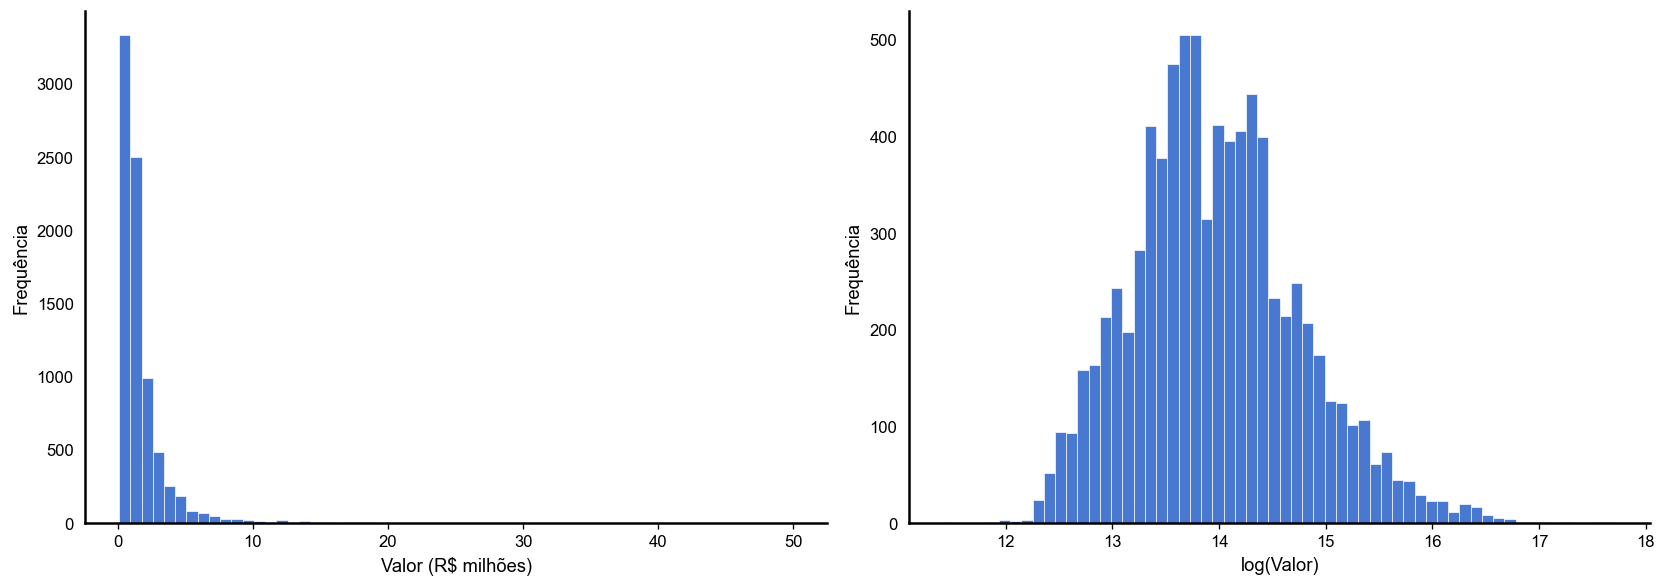

In [97]:
# Figuras 8 e 9 — lado a lado em uma única figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, xlabel in zip(
    axes,
    ['valor', 'log_valor'],
    ['Valor (R$ milhões)', 'log(Valor)']
):
    if var == 'valor':
        dados = df['valor'].dropna() / 1_000_000
    else:
        dados = df['log_valor'].dropna()

    ax.hist(dados, bins=60, color=COR, edgecolor='white', linewidth=0.4)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequência')
    ax.tick_params(left=False)


plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'distribuicao_valor_comparativo.png'),
            bbox_inches='tight', dpi=150)
plt.show()

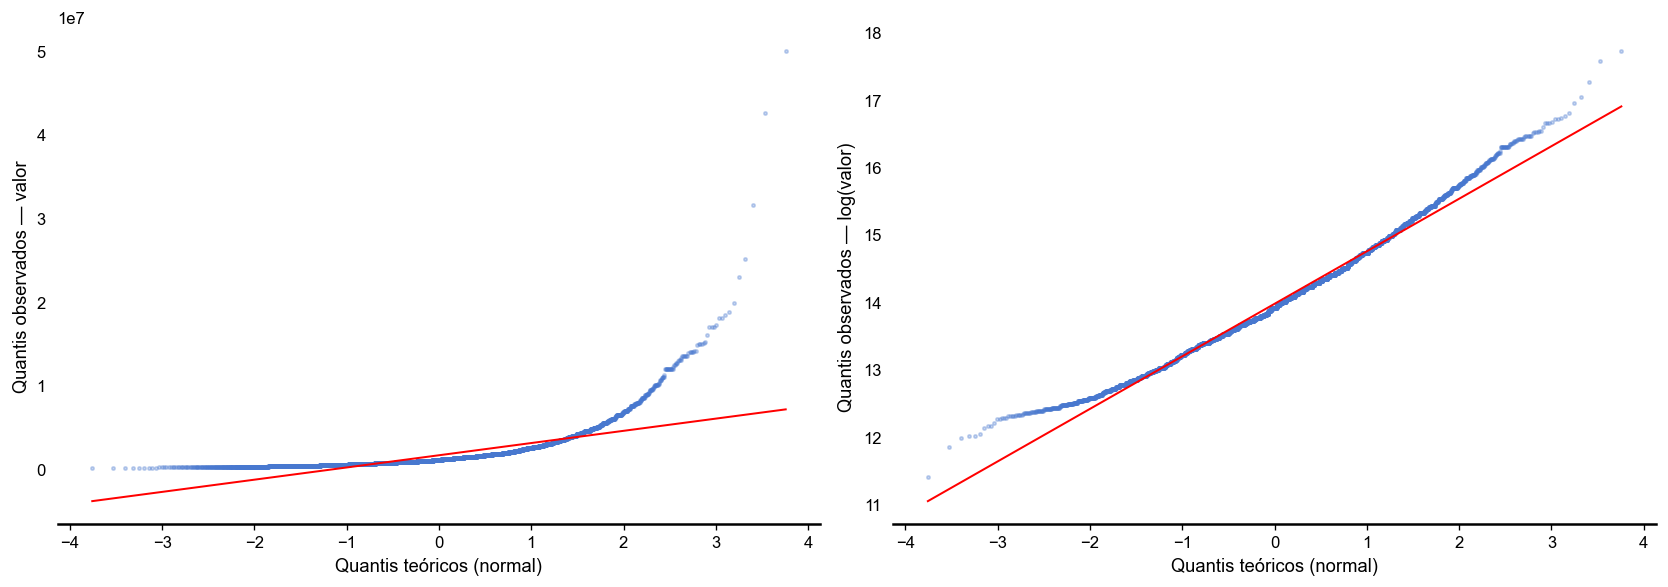

In [55]:
# QQ-plot — valor original vs log(valor)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, var, ylabel in zip(axes,
    ['valor', 'log_valor'],
    ['Quantis observados — valor', 'Quantis observados — log(valor)']):
    stats.probplot(df[var].dropna(), dist='norm', plot=ax)
    ax.get_lines()[0].set(markersize=2, alpha=0.3, color=COR)
    ax.get_lines()[1].set(color='red', linewidth=1.2)
    ax.set_title('')
    ax.set_xlabel('Quantis teóricos (normal)')
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'qqplot_valor_transformacao.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 3 — Distribuições das variáveis numéricas

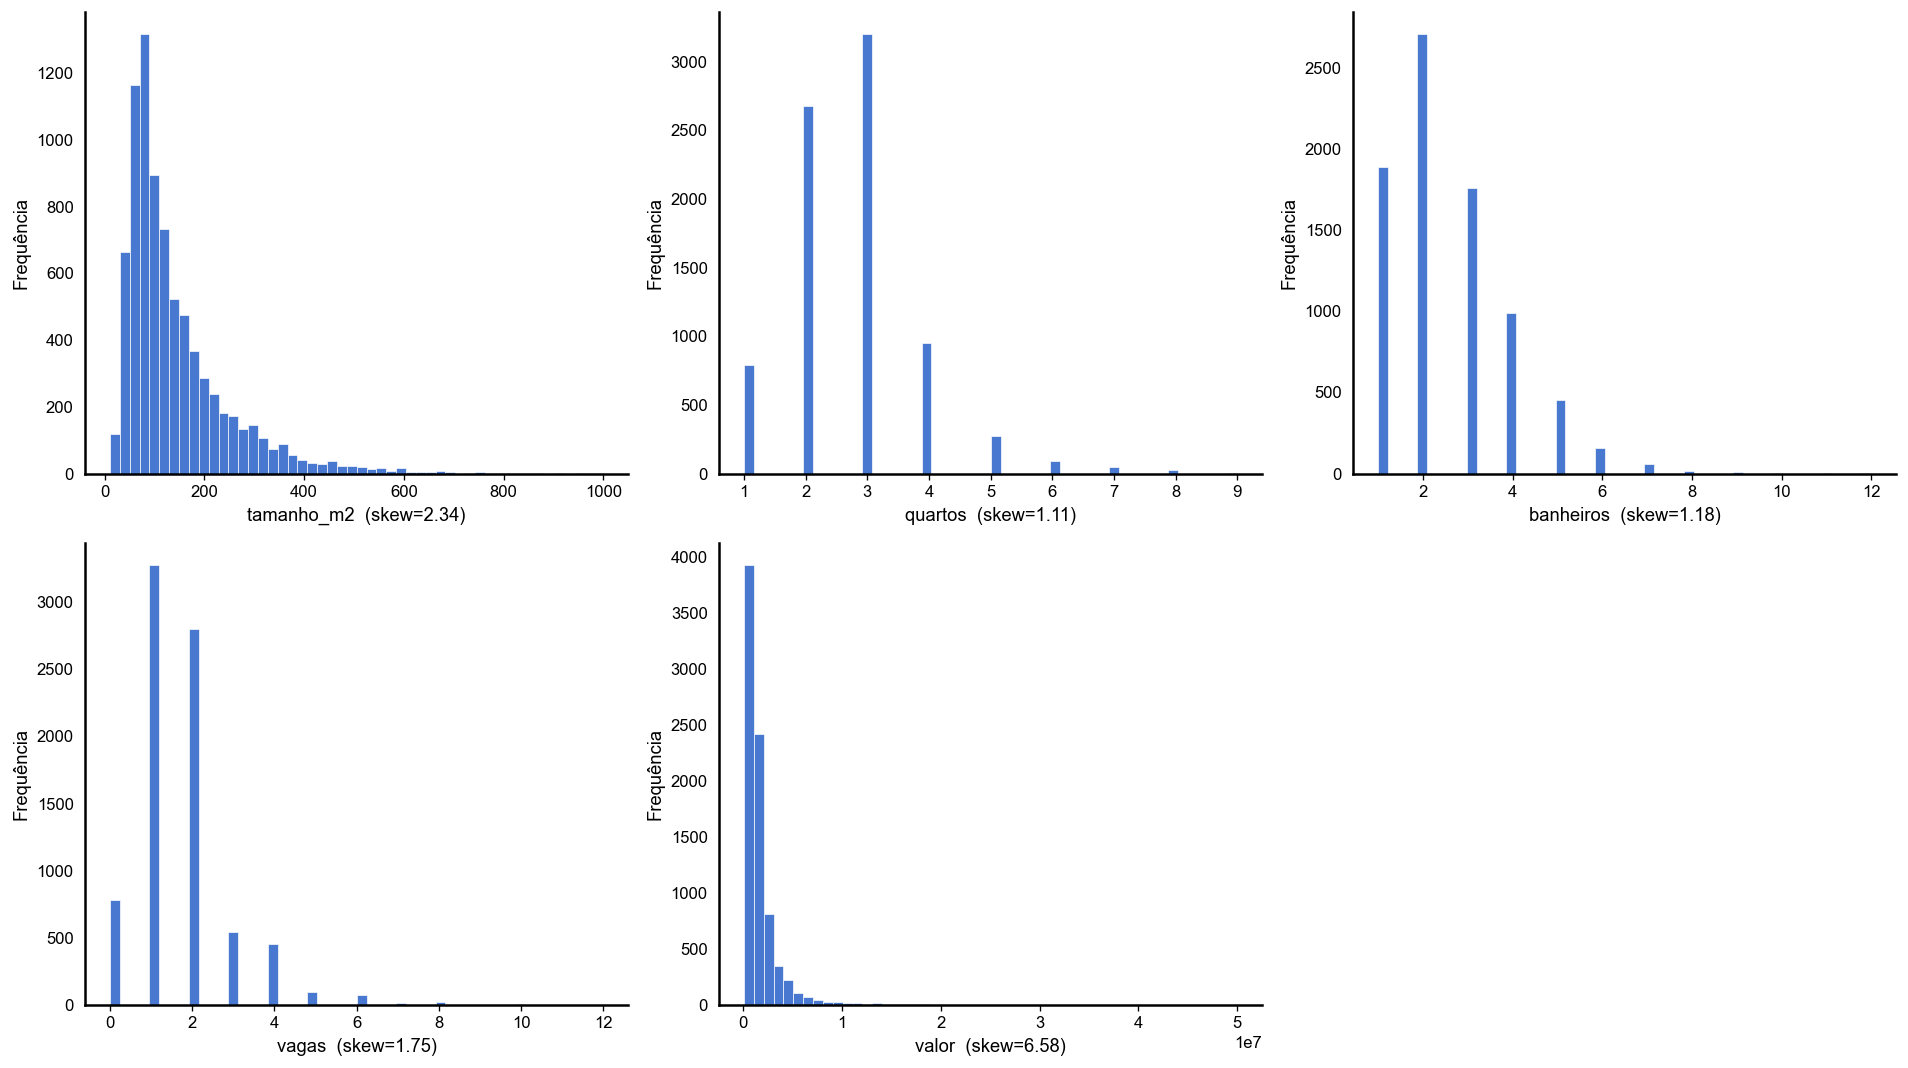

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(NUMERICAS):
    axes[i].hist(df[col].dropna(), bins=50, color=COR, edgecolor='white', linewidth=0.4)
    axes[i].set_xlabel(f'{col}  (skew={df[col].skew():.2f})')
    axes[i].set_ylabel('Frequência')
    axes[i].tick_params(left=False)
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'distribuicoes_numericas.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 4 — Preço/m² por região

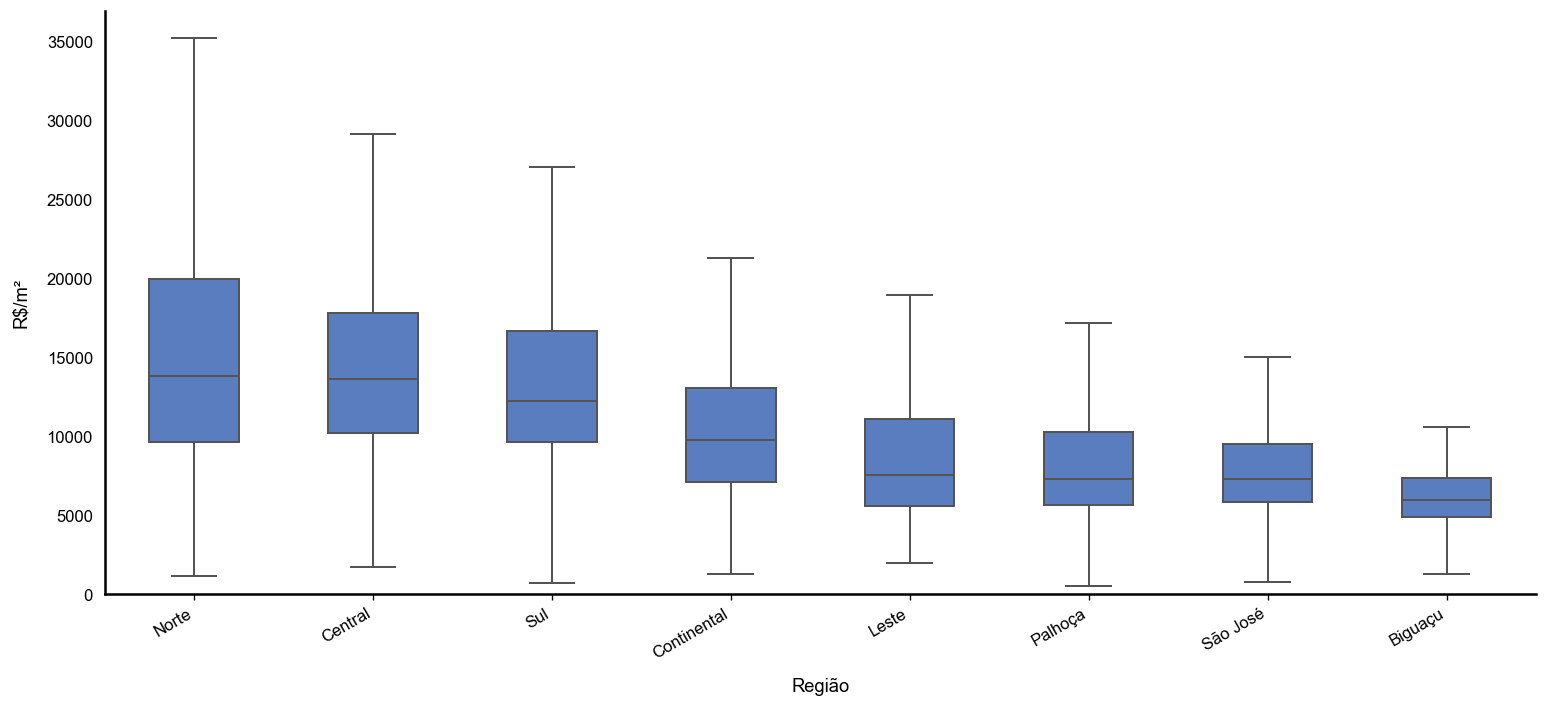

In [57]:
stats_regiao = (df.groupby('regiao', observed=True)['preco_m2']
                  .agg(count='count', media='mean', mediana='median', std='std')
                  .sort_values('mediana', ascending=False).round(0))
stats_regiao.to_csv(os.path.join(SAIDA_DIR,'preco_m2_por_regiao.csv'), encoding='utf-8-sig')
ordem_regiao = stats_regiao.index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x='regiao', y='preco_m2', order=ordem_regiao,
            showfliers=False, ax=ax, width=0.5, linewidth=1.2, color=COR)
ax.set_ylim(bottom=0)
ax.set_xlabel('Região', labelpad=10)
ax.set_ylabel('R$/m²', labelpad=10)
ax.tick_params(left=False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'preco_m2_por_regiao.png'), bbox_inches='tight', dpi=150)
plt.show()

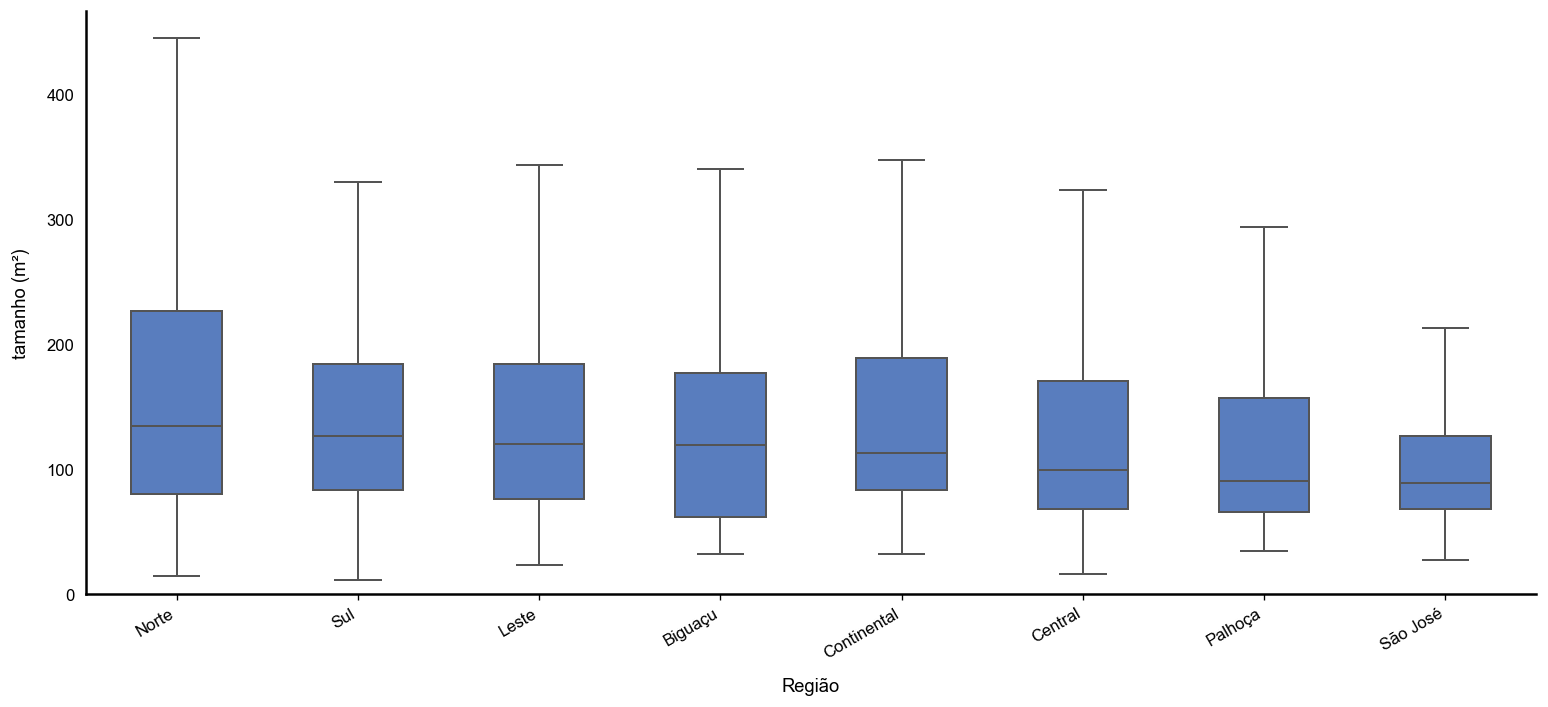

In [81]:
stats_regiao = (df.groupby('regiao', observed=True)['tamanho_m2']
                  .agg(count='count', media='mean', mediana='median', std='std')
                  .sort_values('mediana', ascending=False).round(0))
stats_regiao.to_csv(os.path.join(SAIDA_DIR,'preco_m2_por_regiao.csv'), encoding='utf-8-sig')
ordem_regiao = stats_regiao.index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x='regiao', y='tamanho_m2', order=ordem_regiao,
            showfliers=False, ax=ax, width=0.5, linewidth=1.2, color=COR)
ax.set_ylim(bottom=0)
ax.set_xlabel('Região', labelpad=10)
ax.set_ylabel('tamanho (m²)', labelpad=10)
ax.tick_params(left=False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'tamanho_m2_por_regiao.png'), bbox_inches='tight', dpi=150)
plt.show()

In [58]:
# ── Etapa 4b — Análise por bairro ─────────────────────────────────────────────

# Tabela completa: todos os bairros com região e R$/m² mediano
tabela_bairros = (df.groupby(['regiao', 'bairro'], observed=True)['preco_m2']
                    .agg(mediana='median', n='count')
                    .reset_index()
                    .sort_values('mediana', ascending=False)
                    .round(0))

tabela_bairros.to_csv(os.path.join(SAIDA_DIR, 'preco_m2_por_bairro.csv'),
                      index=False, encoding='utf-8-sig')

print(f'Total de bairros: {len(tabela_bairros)}')
print('\nTop 20 bairros por R$/m² mediano:')
tabela_bairros.head(20)

Total de bairros: 140

Top 20 bairros por R$/m² mediano:


,regiao,bairro,mediana,n
58,Norte,Jurerê,24157.0,210
56,Norte,Forte,23200.0,1
50,Leste,Praia Mole,23190.0,11
48,Leste,Canto da Lagoa,20699.0,2
59,Norte,Jurerê Internacional,19892.0,147
53,Norte,Cacupé,16816.0,138
103,Sul,Morro das Pedras,15000.0,83
22,Central,Agronômica,15000.0,171
32,Central,Saco Grande,14872.0,142
61,Norte,Praia Brava,14744.0,37


In [59]:
# Tabela completa para visualização
tabela_bairros

,regiao,bairro,mediana,n
58,Norte,Jurerê,24157.0,210
56,Norte,Forte,23200.0,1
50,Leste,Praia Mole,23190.0,11
48,Leste,Canto da Lagoa,20699.0,2
59,Norte,Jurerê Internacional,19892.0,147
...,...,...,...,...
74,Palhoça,Caminho Novo,3413.0,7
8,Biguaçu,Fazenda De Dentro,3150.0,1
11,Biguaçu,Mar Das Pedras,2576.0,1
139,São José,São Luís,2242.0,1


In [60]:
# Bairros da região Norte com mínimo de observações para análise confiável
norte = (df[df['regiao'] == 'Norte']
           .groupby('bairro', observed=True)['preco_m2']
           .agg(mediana='median', n='count')
           .reset_index()
           .query('n >= 5')           # filtra bairros com menos de 5 obs
           .sort_values('mediana', ascending=False))

print('Bairros da região Norte (n ≥ 5 obs):')
print(norte.to_string(index=False))

bairro_max = norte.iloc[0]['bairro']
bairro_min = norte.iloc[-1]['bairro']
med_max    = norte.iloc[0]['mediana']
med_min    = norte.iloc[-1]['mediana']

print(f'\nMaior R$/m²: {bairro_max} — R$ {med_max:,.0f}/m²')
print(f'Menor R$/m²: {bairro_min} — R$ {med_min:,.0f}/m²')

Bairros da região Norte (n ≥ 5 obs):
                 bairro      mediana   n
                 Jurerê 24156.504065 210
   Jurerê Internacional 19892.473118 147
                 Cacupé 16816.377054 138
            Praia Brava 14743.589744  37
Santo Antônio de Lisboa 12080.536913  63
           Canasvieiras 11402.439024 223
 Cachoeira do Bom Jesus 11055.900621 139
                Ratones 10853.333333  10
        Ponta das Canas  9987.500000  25
                Daniela  9906.638199  24
               Sambaqui  9844.924812  26
         Vargem Pequena  9444.634313  12
               Ingleses  9289.617486 151
               Santinho  9146.341463  13
    Vargem do Bom Jesus  8226.157407  32
          Vargem Grande  7813.529412  22

Maior R$/m²: Jurerê — R$ 24,157/m²
Menor R$/m²: Vargem Grande — R$ 7,814/m²


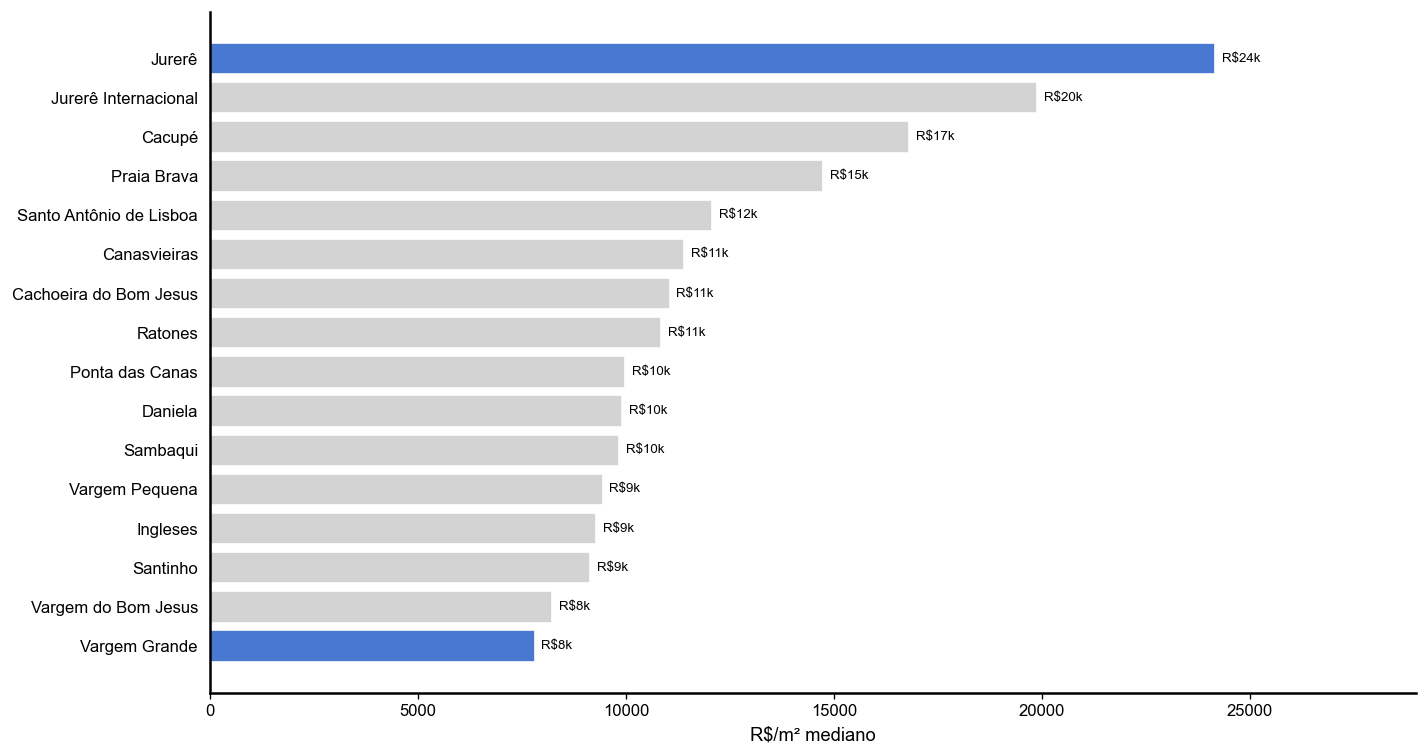

In [61]:
# Gráfico 1 — Barras: todos os bairros da região Norte ordenados por R$/m²
fig, ax = plt.subplots(figsize=(12, max(5, len(norte) * 0.4)))

cores_barra = [
    COR if b == bairro_max else
    COR if b == bairro_min else
    '#D3D3D3'
    for b in norte['bairro']
]

bars = ax.barh(norte['bairro'], norte['mediana'],
               color=cores_barra, edgecolor='white')
ax.bar_label(bars,
             labels=[f'R${v/1e3:.0f}k' for v in norte['mediana']],
             padding=4, fontsize=8)
ax.set_xlabel('R$/m² mediano')
ax.set_xlim(0, norte['mediana'].max() * 1.2)
ax.tick_params(left=False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'preco_m2_bairros_norte.png'),
            bbox_inches='tight', dpi=150)
plt.show()

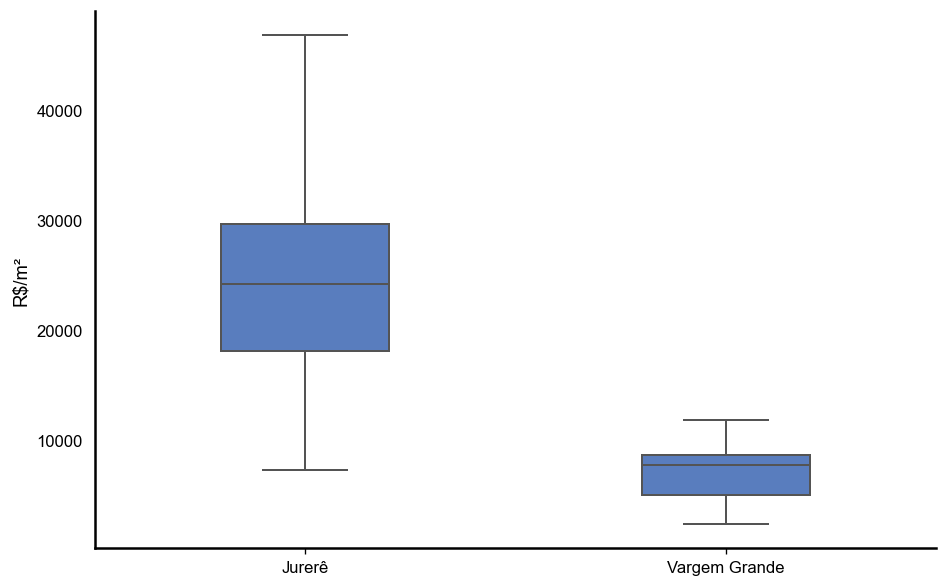

               mediana    media  desvio    n
bairro                                      
Jurerê         24157.0  25236.0  9603.0  210
Vargem Grande   7814.0   7223.0  2571.0   22


In [62]:
# Gráfico 2 — Boxplot comparando o bairro de maior e menor R$/m² dentro do Norte
df_comp = df[
    (df['regiao'] == 'Norte') &
    (df['bairro'].isin([bairro_max, bairro_min]))
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_comp, x='bairro', y='preco_m2',
            order=[bairro_max, bairro_min],
            showfliers=False, ax=ax,
            palette={bairro_max: COR, bairro_min: COR},
            width=0.4, linewidth=1.2)

ax.set_xlabel('')
ax.set_ylabel('R$/m²')
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'boxplot_bairros_extremos_norte.png'),
            bbox_inches='tight', dpi=150)
plt.show()

# Estatísticas dos dois bairros
print(df_comp.groupby('bairro', observed=True)['preco_m2']
             .agg(mediana='median', media='mean', desvio='std', n='count')
             .round(0))

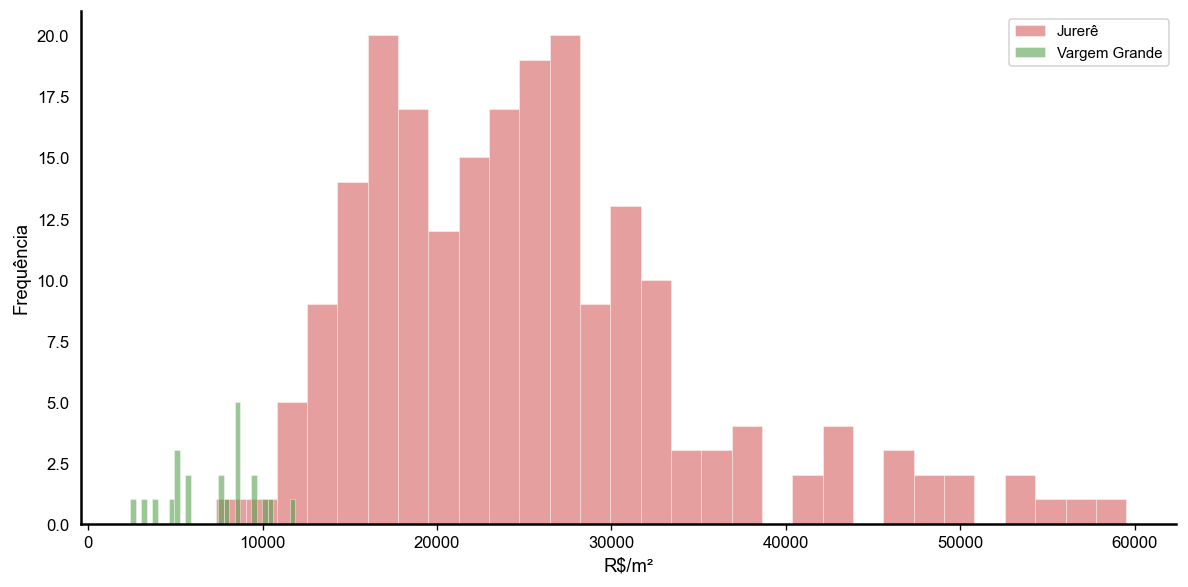

In [63]:
# Gráfico 3 — Histogramas sobrepostos dos dois bairros extremos
df_max = df[(df['regiao'] == 'Norte') & (df['bairro'] == bairro_max)]['preco_m2'].dropna()
df_min = df[(df['regiao'] == 'Norte') & (df['bairro'] == bairro_min)]['preco_m2'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_max, bins=30, alpha=0.6, color='#D65F5F',
        edgecolor='white', linewidth=0.4, label=bairro_max)
ax.hist(df_min, bins=30, alpha=0.6, color='#59A14F',
        edgecolor='white', linewidth=0.4, label=bairro_min)
ax.set_xlabel('R$/m²')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'hist_bairros_extremos_norte.png'),
            bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 5 — Correlações

In [64]:
print(f"{'Variável':<15} {'rho':>8}  {'p-valor':>12}  sig")
print('-' * 42)
resultados_sp = []
for col in ['tamanho_m2','quartos','banheiros','vagas']:
    dados = df[['valor', col]].dropna()
    rho, p = stats.spearmanr(dados['valor'], dados[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'{col:<15} {rho:>8.3f}  {p:>12.4e}  {sig}')
    resultados_sp.append({'variavel': col, 'rho': round(rho,4), 'p_valor': round(p,6)})
pd.DataFrame(resultados_sp).to_csv(os.path.join(SAIDA_DIR,'correlacao_spearman.csv'),
                                   index=False, encoding='utf-8-sig')

Variável             rho       p-valor  sig
------------------------------------------
tamanho_m2         0.733    0.0000e+00  ***
quartos            0.580    0.0000e+00  ***
banheiros          0.690    0.0000e+00  ***
vagas              0.556    0.0000e+00  ***


In [65]:
print(f"{'Amenidade':<25} {'r':>8}  {'p-valor':>12}  sig")
print('-' * 52)
resultados_pb = []
for col in AMENIDADES:
    dados = df[['valor', col]].dropna()
    r, p  = pointbiserialr(dados[col], dados['valor'])
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'{col:<25} {r:>8.3f}  {p:>12.4e}  {sig}')
    resultados_pb.append({'amenidade': col, 'r': round(r,4), 'p_valor': round(p,6)})
pd.DataFrame(resultados_pb).to_csv(os.path.join(SAIDA_DIR,'correlacao_point_biserial.csv'),
                                   index=False, encoding='utf-8-sig')

Amenidade                        r       p-valor  sig
----------------------------------------------------
piscina                      0.262   1.0533e-126  ***
sacada                       0.148    5.9408e-41  ***
churrasqueira                0.166    5.7534e-51  ***
imovel_mobiliado             0.042    1.3838e-04  ***
elevador                     0.012    2.8558e-01  
academia                    -0.049    1.0981e-05  ***
salao_de_festas              0.023    3.7870e-02  *


---
## Etapa 6 — Boxplots por grupo + Kruskal-Wallis

In [66]:
grupos_r = [g['valor'].dropna().values for _, g in df.groupby('regiao', observed=True)]
grupos_t = [g['valor'].dropna().values for _, g in df.groupby('tipo',   observed=True)]
h_r, p_r = kruskal(*grupos_r)
h_t, p_t = kruskal(*grupos_t)
print(f'Kruskal-Wallis por região: H={h_r:.2f}  p={p_r:.4e}')
print(f'Kruskal-Wallis por tipo:   H={h_t:.2f}  p={p_t:.4e}')

Kruskal-Wallis por região: H=1633.21  p=0.0000e+00
Kruskal-Wallis por tipo:   H=204.43  p=2.2503e-46


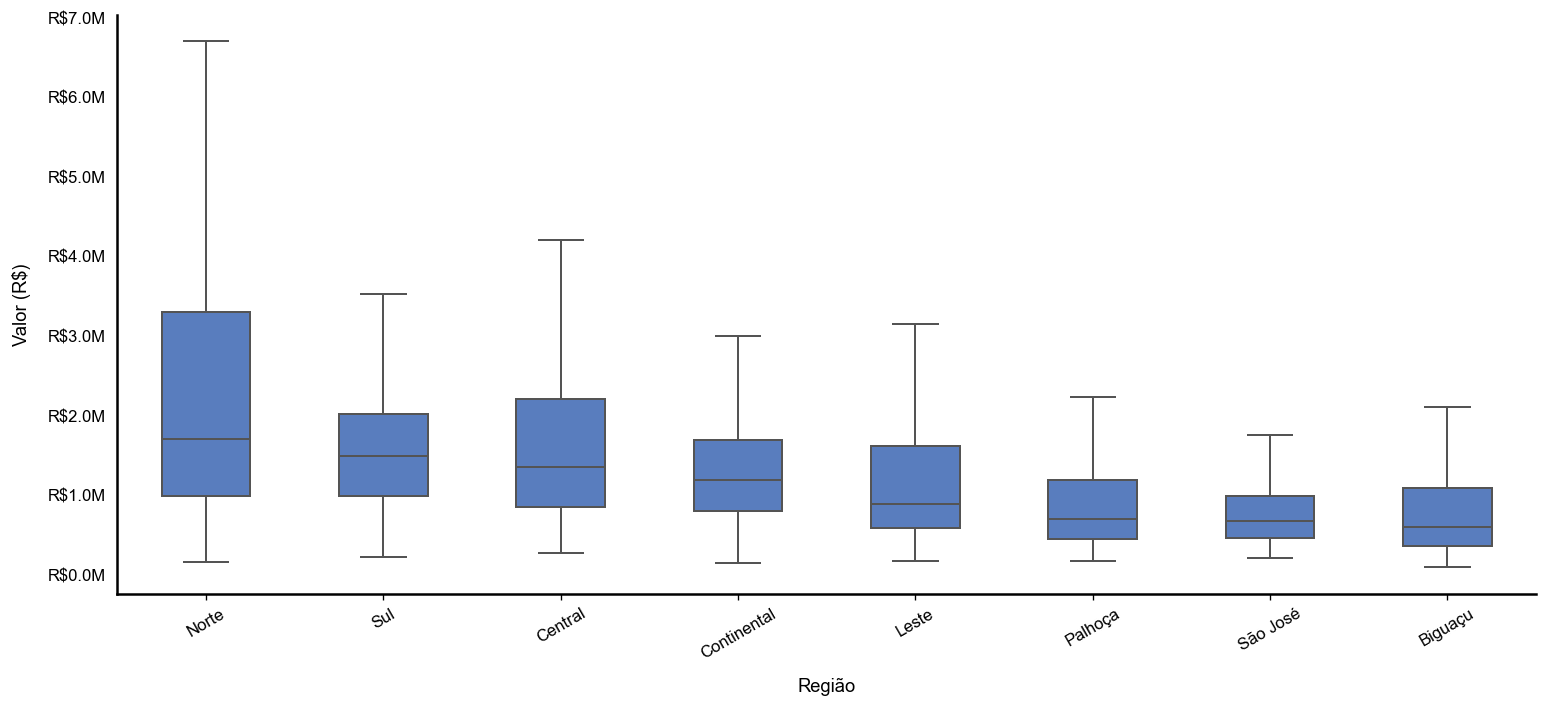

In [67]:
ordem_v = df.groupby('regiao', observed=True)['valor'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x='regiao', y='valor', order=ordem_v,
            showfliers=False, ax=ax, color=COR, width=0.5, linewidth=1.2)
ax.set_xlabel('Região', labelpad=10)
ax.set_ylabel('Valor (R$)', labelpad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=30)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'boxplot_valor_por_regiao.png'), bbox_inches='tight', dpi=150)
plt.show()

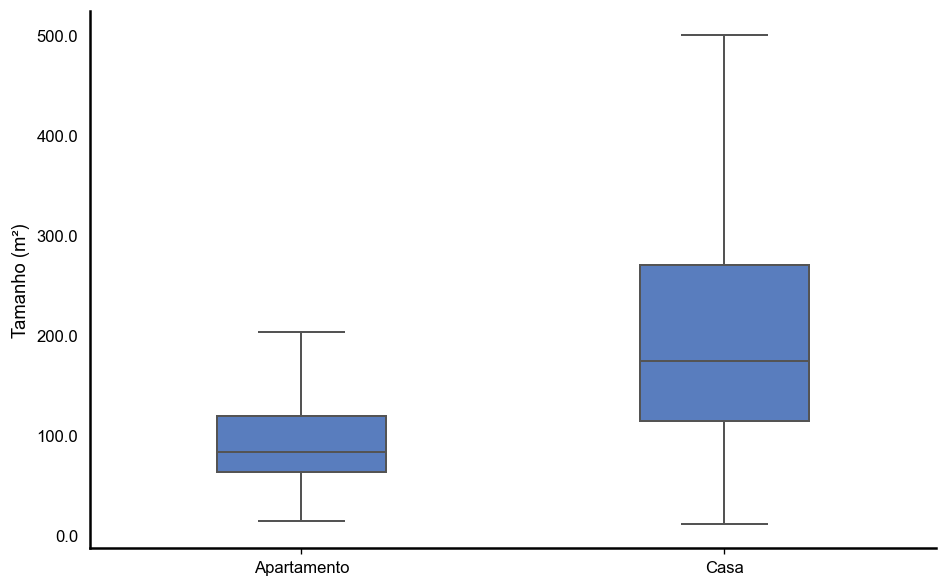

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='tipo', y='tamanho_m2', showfliers=False,
            ax=ax, color=COR, width=0.4, linewidth=1.2)
ax.set_xlabel('')
ax.set_ylabel('Tamanho (m²)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'boxplot_tamanho_por_tipo.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 6b — Análise comparativa por tipo e região

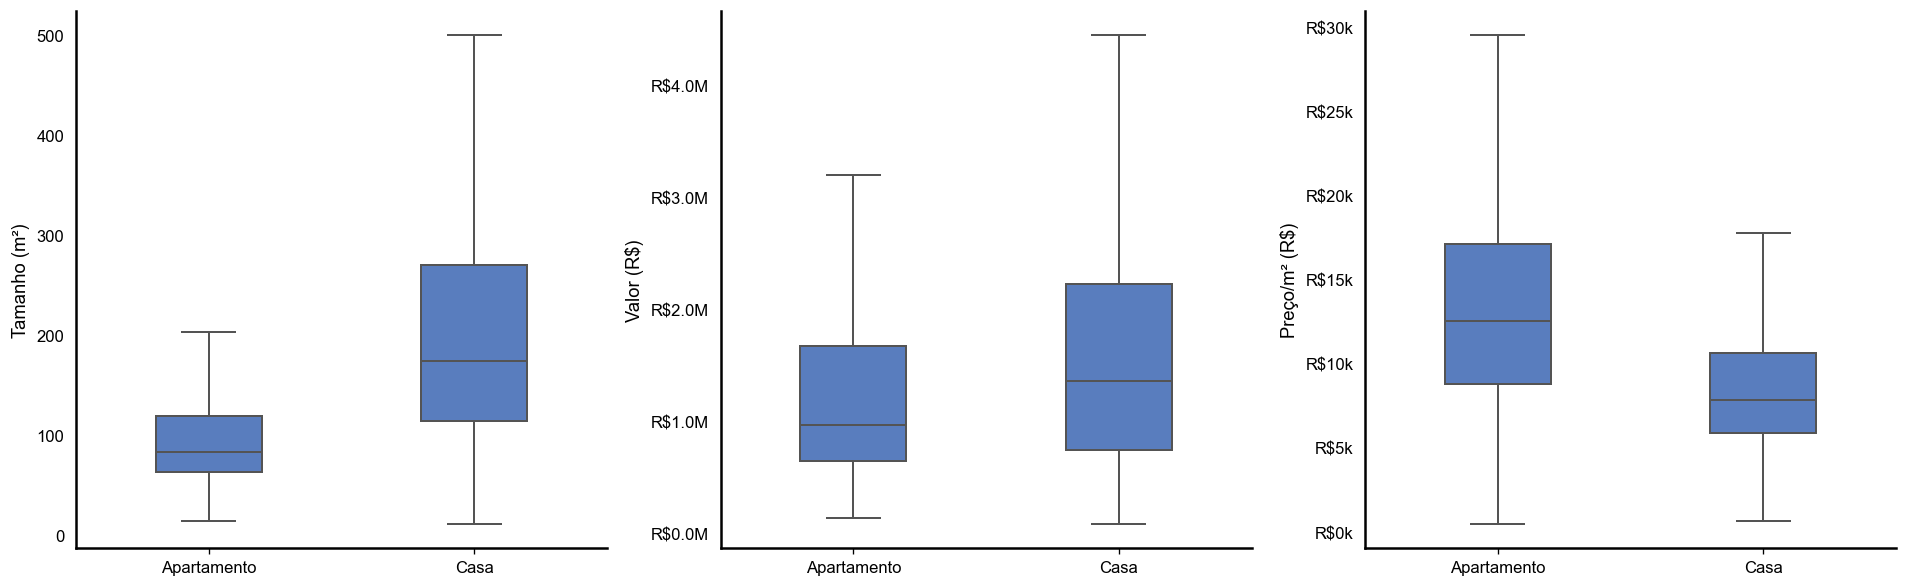

In [69]:
# Tamanho, valor e preço/m² por tipo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [
    ('tamanho_m2', 'Tamanho (m²)',  lambda x,_: f'{x:.0f}'),
    ('valor',      'Valor (R$)',    lambda x,_: f'R${x/1e6:.1f}M'),
    ('preco_m2',   'Preço/m² (R$)',  lambda x,_: f'R${x/1e3:.0f}k'),
]
for ax, (var, ylabel, fmt) in zip(axes, configs):
    sns.boxplot(data=df, x='tipo', y=var, showfliers=False,
                ax=ax, color=COR, width=0.4, linewidth=1.2)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))
    ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'boxplot_tipo_comparativo.png'), bbox_inches='tight', dpi=150)
plt.show()

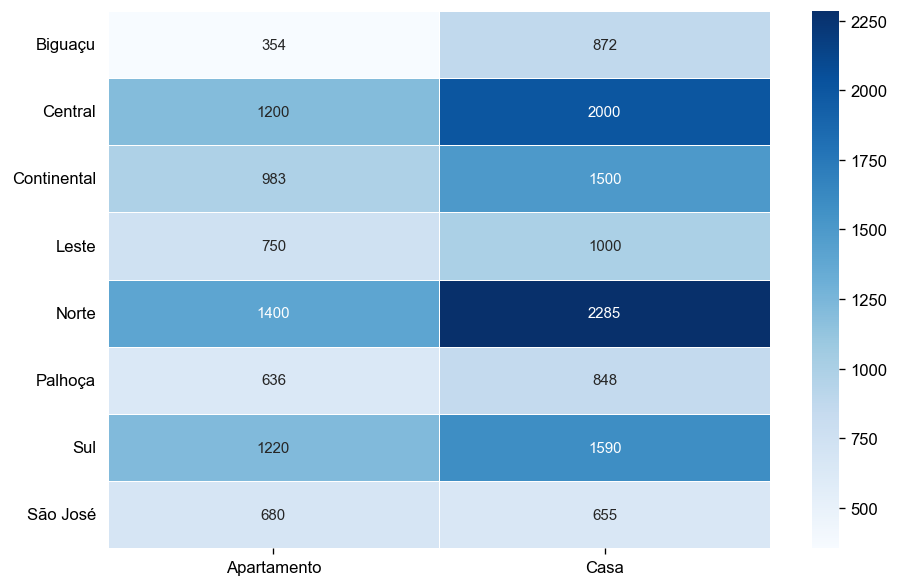

Valor mediano (R$ mil):
tipo         Apartamento    Casa
regiao                          
Biguaçu            354.0   872.0
Central           1200.0  2000.0
Continental        983.0  1500.0
Leste              750.0  1000.0
Norte             1400.0  2285.0
Palhoça            636.0   848.0
Sul               1220.0  1590.0
São José           680.0   655.0


In [70]:
# Heatmap valor mediano por tipo × região
pivot_k = df.pivot_table(values='valor', index='regiao', columns='tipo', aggfunc='median') / 1000
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_k, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'heatmap_valor_tipo_regiao.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Valor mediano (R$ mil):')
print(pivot_k.round(0).to_string())

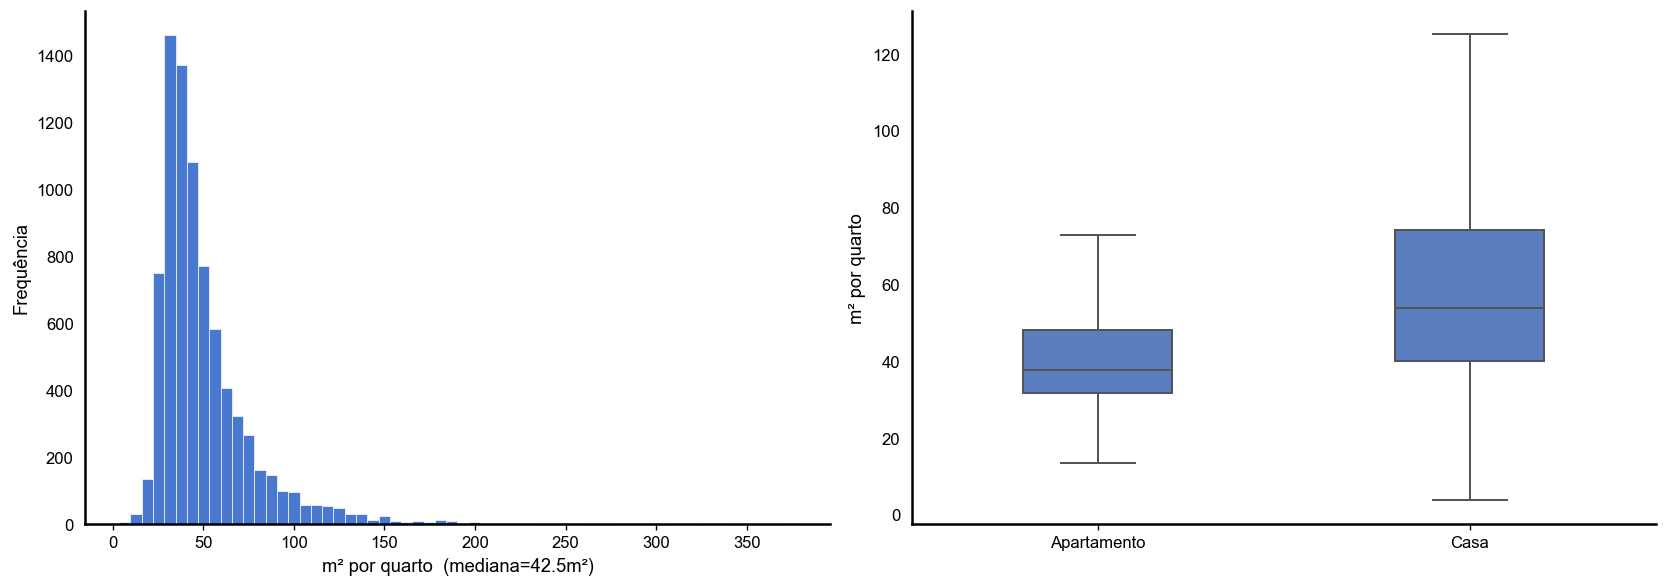

             mean  median   std
tipo                           
Apartamento  42.6    37.7  20.3
Casa         62.0    53.7  33.0


In [71]:
# m² por quarto — histograma e boxplot por tipo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['m2_por_quarto'].dropna(), bins=60,
             color=COR, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel(f"m² por quarto  (mediana={df['m2_por_quarto'].median():.1f}m²)")
axes[0].set_ylabel('Frequência')
axes[0].tick_params(left=False)
sns.boxplot(data=df, x='tipo', y='m2_por_quarto', showfliers=False,
            ax=axes[1], color=COR, width=0.4, linewidth=1.2)
axes[1].set_xlabel('')
axes[1].set_ylabel('m² por quarto')
axes[1].tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'m2_por_quarto.png'), bbox_inches='tight', dpi=150)
plt.show()
print(df.groupby('tipo', observed=True)['m2_por_quarto']
        .agg(['mean','median','std']).round(1))

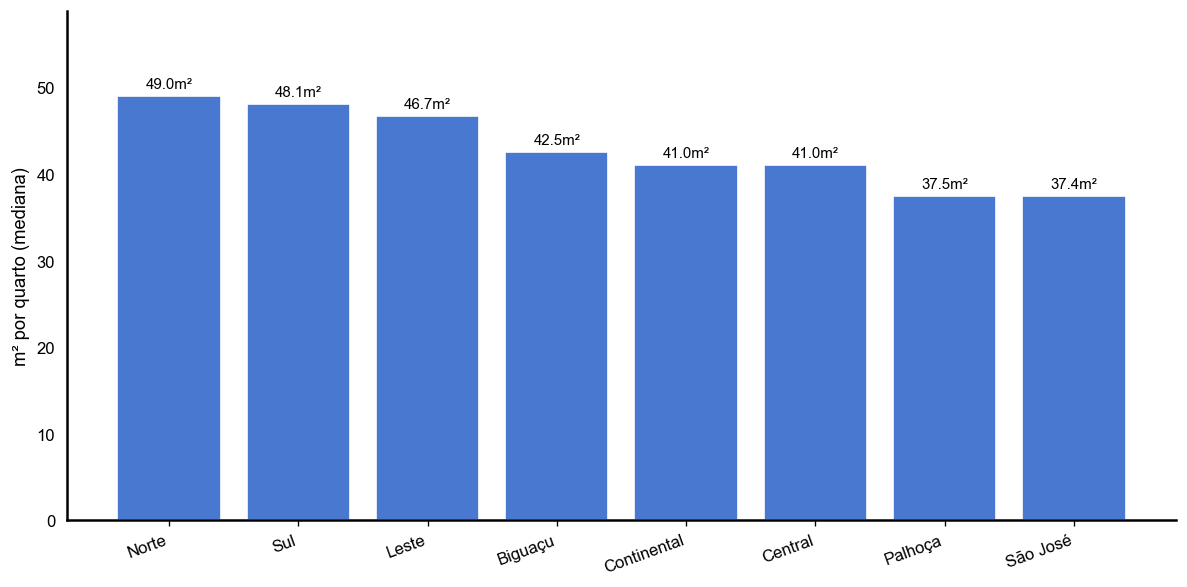

In [72]:
# m² por quarto por região
ordem_m2q = df.groupby('regiao', observed=True)['m2_por_quarto'].median().sort_values(ascending=False)
fig, ax   = plt.subplots(figsize=(10, 5))
bars = ax.bar(ordem_m2q.index, ordem_m2q.values, color=COR, edgecolor='white')
ax.bar_label(bars, fmt='%.1fm²', padding=3, fontsize=9)
ax.set_ylabel('m² por quarto (mediana)')
ax.set_ylim(0, ordem_m2q.max() * 1.2)
ax.tick_params(left=False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'m2_quarto_por_regiao.png'), bbox_inches='tight', dpi=150)
plt.show()

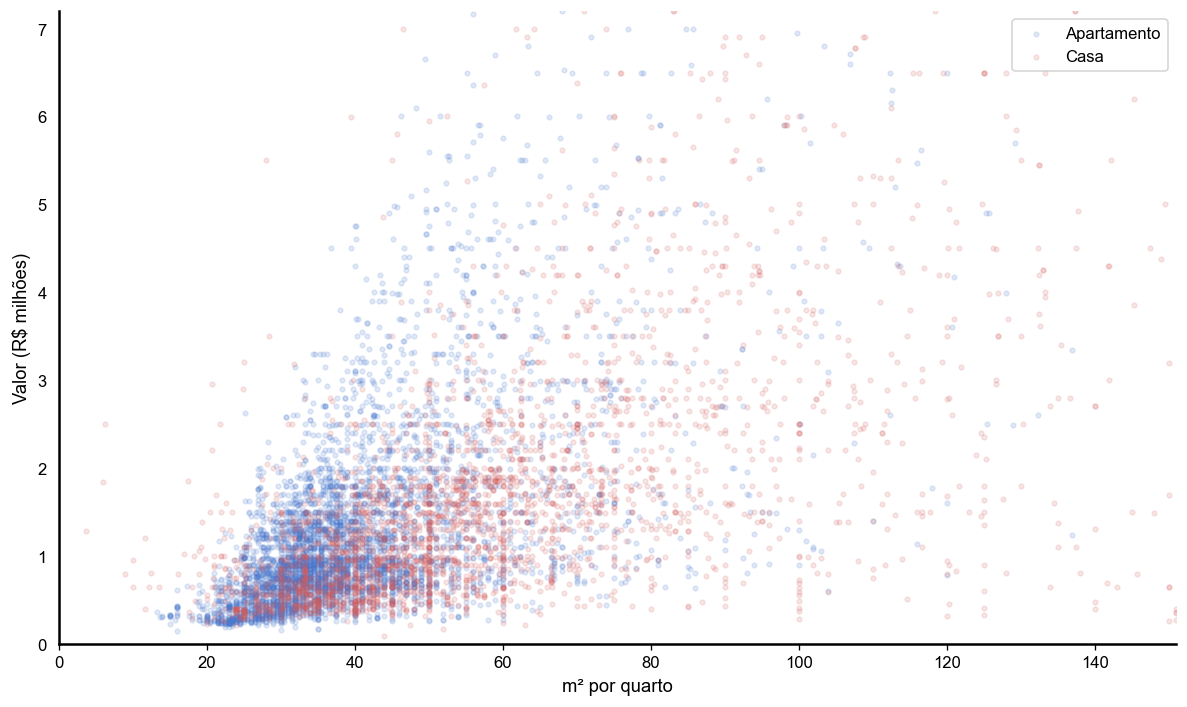

In [73]:
# Scatter m² por quarto vs valor, por tipo
fig, ax = plt.subplots(figsize=(10, 6))
cores_t = {'Apartamento': COR, 'Casa': '#D65F5F'}
for tipo, grupo in df.groupby('tipo', observed=True):
    ax.scatter(grupo['m2_por_quarto'], grupo['valor']/1e6,
               alpha=0.15, s=8, color=cores_t.get(str(tipo), COR), label=str(tipo))
ax.set_xlabel('m² por quarto')
ax.set_ylabel('Valor (R$ milhões)')
ax.set_xlim(0, df['m2_por_quarto'].quantile(0.99))
ax.set_ylim(0, df['valor'].quantile(0.98)/1e6)
ax.legend()
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'scatter_m2_quarto_valor.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 7 — Impacto das amenidades

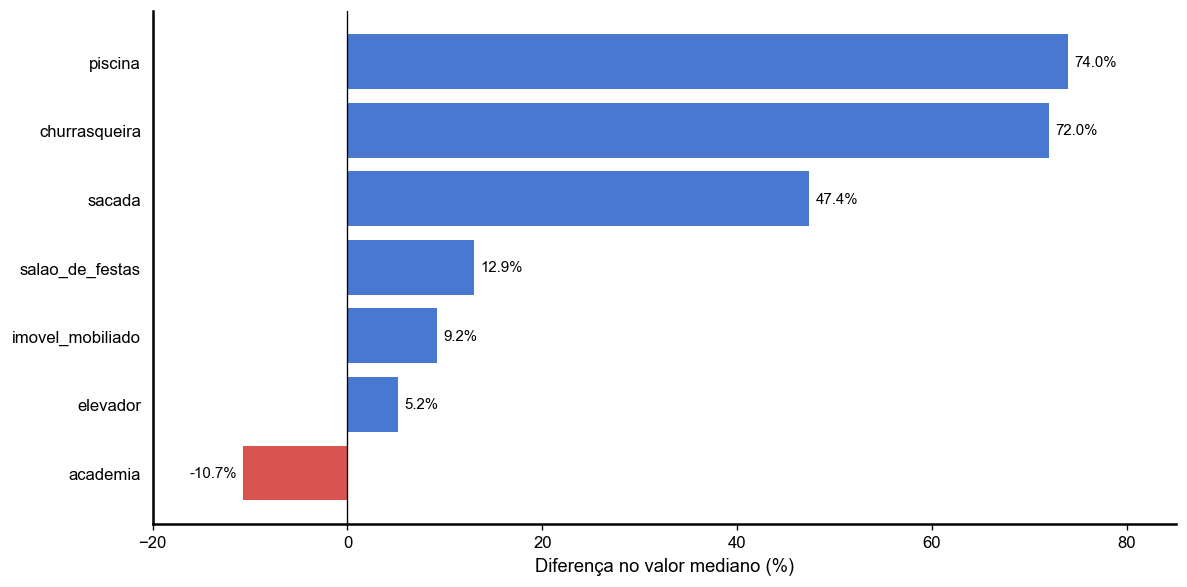

In [88]:
resultados_am = []
for col in AMENIDADES:
    mc  = df[df[col]==1]['valor'].median()
    ms  = df[df[col]==0]['valor'].median()
    dp  = 100*(mc-ms)/ms
    resultados_am.append({'amenidade':col,'mediana_com':round(mc,0),'mediana_sem':round(ms,0),
                          'delta_pct':round(dp,2),'n_com':int(df[col].sum())})
df_am = pd.DataFrame(resultados_am).sort_values('delta_pct', ascending=True)
df_am.to_csv(os.path.join(SAIDA_DIR,'amenidades_impacto.csv'), index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#d9534f' if x < 0 else COR for x in df_am['delta_pct']]
bars  = ax.barh(df_am['amenidade'], df_am['delta_pct'], color=cores)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferença no valor mediano (%)')
ax.set_xlim(-20, df_am['delta_pct'].max() * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'amenidades_impacto.png'), bbox_inches='tight', dpi=150)
plt.show()

In [95]:
for col in AMENIDADES:
    mc = df[df[col]==1]['valor'].median()
    ms = df[df[col]==0]['valor'].median()
    dp = 100*(mc-ms)/ms
    print(f"{col:<20} mediana_com={mc:,.0f}  mediana_sem={ms:,.0f}  delta={dp:.1f}%")

piscina              mediana_com=1,555,004  mediana_sem=893,856  delta=74.0%
sacada               mediana_com=1,400,000  mediana_sem=950,000  delta=47.4%
churrasqueira        mediana_com=1,290,000  mediana_sem=750,000  delta=72.0%
imovel_mobiliado     mediana_com=1,190,000  mediana_sem=1,090,000  delta=9.2%
elevador             mediana_com=1,146,529  mediana_sem=1,090,000  delta=5.2%
academia             mediana_com=982,542  mediana_sem=1,100,000  delta=-10.7%
salao_de_festas      mediana_com=1,180,250  mediana_sem=1,045,000  delta=12.9%


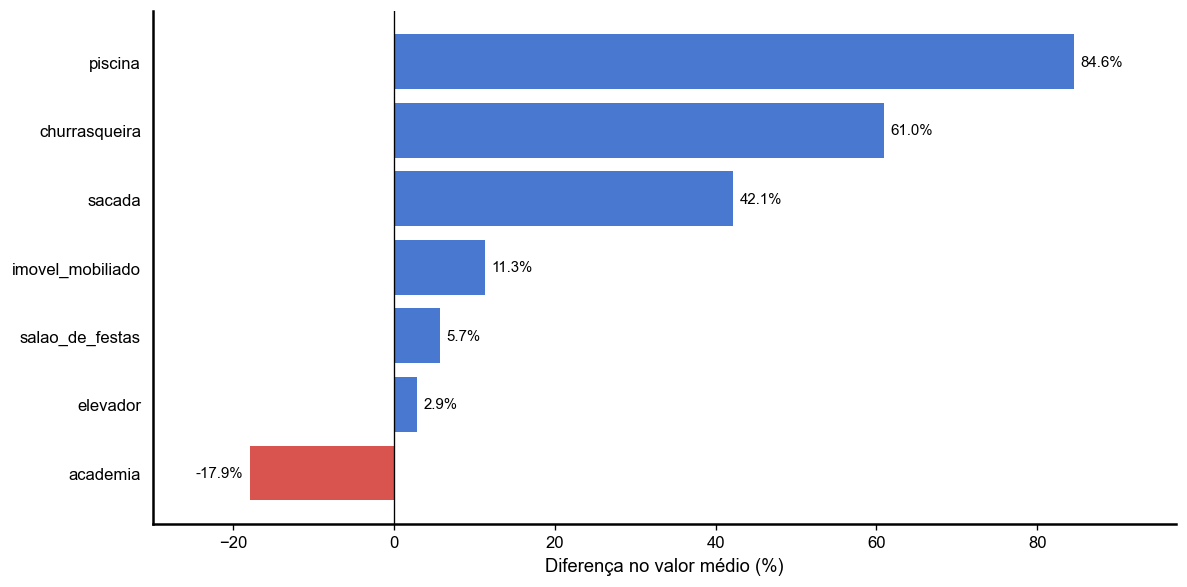

       amenidade  media_com  media_sem  delta_pct  n_com
        academia  1387052.0  1689695.0     -17.91    910
        elevador  1684387.0  1636745.0       2.91   3174
 salao_de_festas  1711067.0  1618646.0       5.71   3214
imovel_mobiliado  1781547.0  1600797.0      11.29   2439
          sacada  2045875.0  1439289.0      42.14   2872
   churrasqueira  1869387.0  1161424.0      60.96   5623
         piscina  2287161.0  1239141.0      84.58   3201


In [94]:
resultados_am = []
for col in AMENIDADES:
    mc  = df[df[col]==1]['valor'].mean()
    ms  = df[df[col]==0]['valor'].mean()
    dp  = 100*(mc-ms)/ms
    resultados_am.append({'amenidade':col,'media_com':round(mc,0),'media_sem':round(ms,0),
                          'delta_pct':round(dp,2),'n_com':int(df[col].sum())})
df_am = pd.DataFrame(resultados_am).sort_values('delta_pct', ascending=True)
df_am.to_csv(os.path.join(SAIDA_DIR,'amenidades_impacto.csv'), index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#d9534f' if x < 0 else COR for x in df_am['delta_pct']]
bars  = ax.barh(df_am['amenidade'], df_am['delta_pct'], color=cores)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferença no valor médio (%)')
ax.set_xlim(-30, df_am['delta_pct'].max() * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'amenidades_impacto.png'), bbox_inches='tight', dpi=150)
plt.show()

print(df_am[['amenidade','media_com','media_sem','delta_pct','n_com']].to_string(index=False))

---
## Etapa 8 — Matriz de correlação (Spearman)

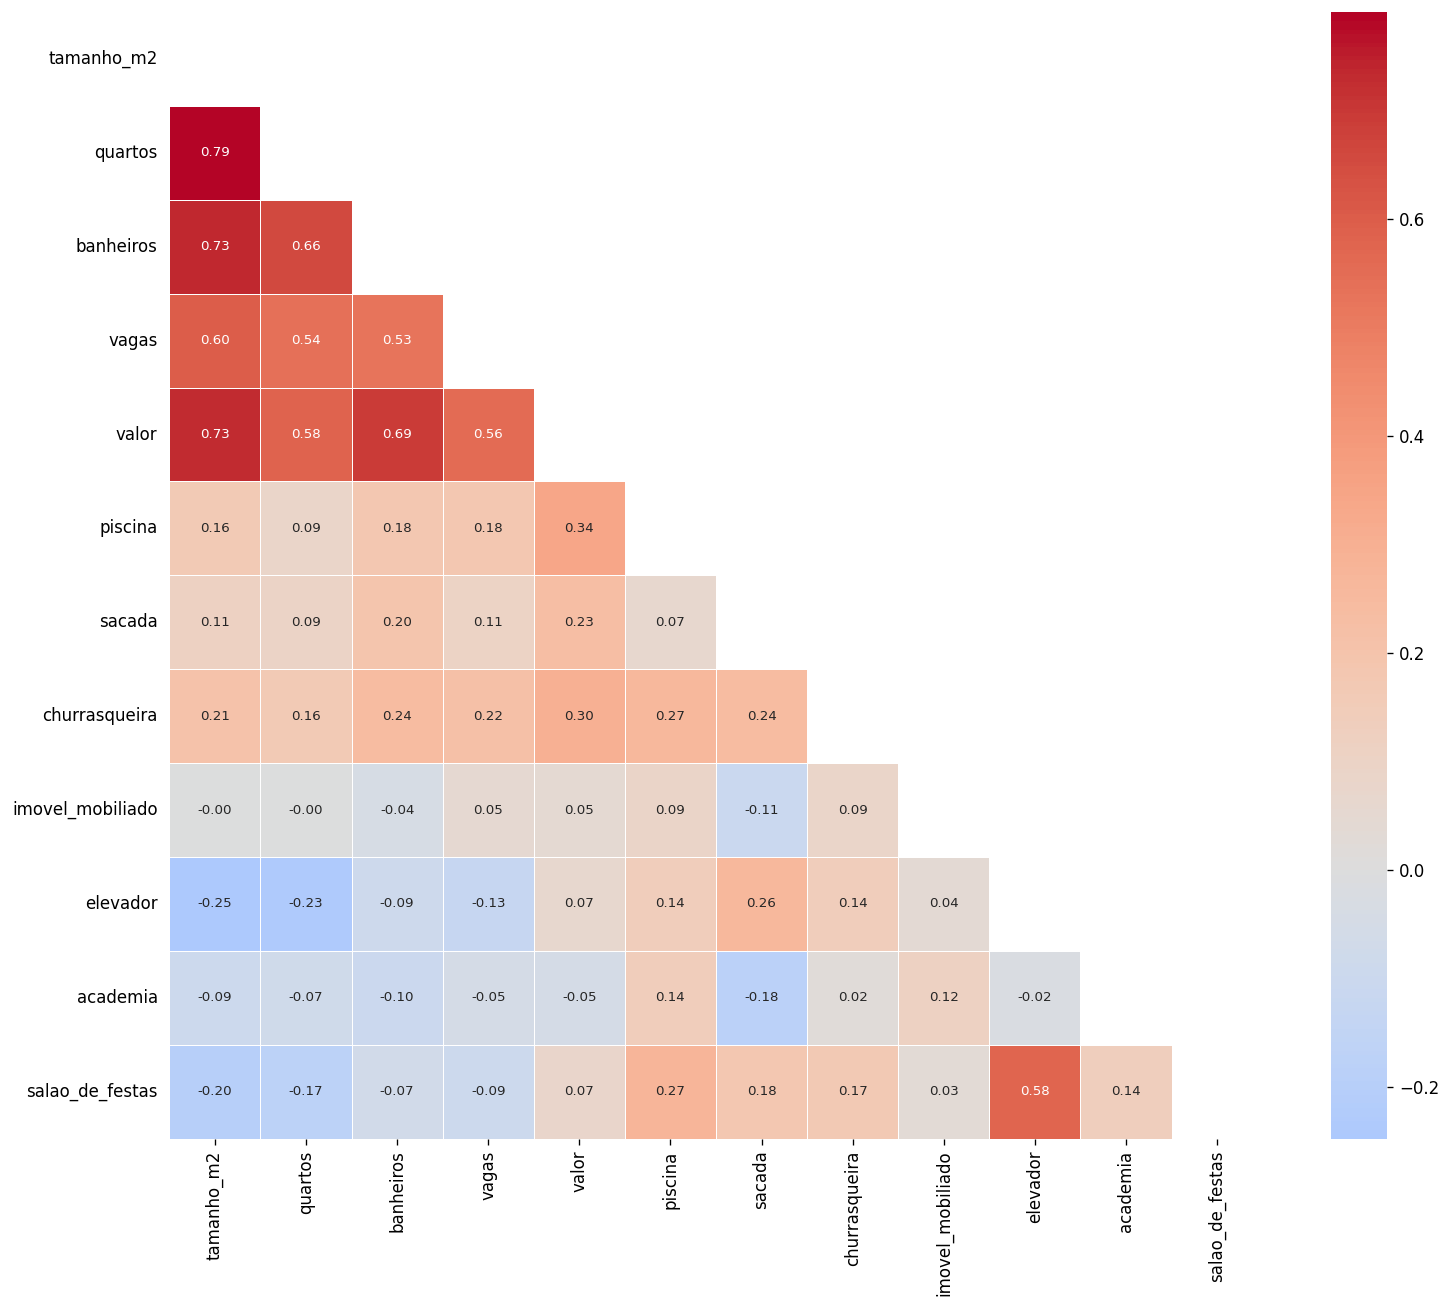

In [26]:
cols_corr = NUMERICAS + AMENIDADES
corr_matrix, _ = spearmanr(df[cols_corr].dropna())
corr = pd.DataFrame(corr_matrix, index=cols_corr, columns=cols_corr)

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR,'matriz_correlacao.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 9 — VIF

In [79]:
df_vif = pd.get_dummies(
    df[['tamanho_m2','quartos','banheiros','vagas'] + AMENIDADES + CATEGORICAS].dropna(),
    columns=CATEGORICAS, drop_first=True
).astype(float)

vif_data = pd.DataFrame({
    'variavel': df_vif.columns,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
}).sort_values('VIF', ascending=False).round(2)

vif_data.to_csv(os.path.join(SAIDA_DIR,'vif.csv'), index=False, encoding='utf-8-sig')
problemas = vif_data[vif_data['VIF'] > 10]
if len(problemas):
    print(f'⚠ {len(problemas)} variável(is) com VIF > 10:')
    print(problemas.to_string(index=False))
else:
    print('✓ Nenhuma variável com VIF > 10.')
vif_data

⚠ 2 variável(is) com VIF > 10:
 variavel   VIF
  quartos 15.41
banheiros 10.32


,variavel,VIF
1,quartos,15.41
2,banheiros,10.32
0,tamanho_m2,6.55
3,vagas,4.67
6,churrasqueira,4.02
18,tipo_Casa,3.98
11,regiao_Central,3.71
8,elevador,3.46
10,salao_de_festas,2.98
14,regiao_Norte,2.65


---
## Relatório final

In [80]:
print('EDA CONCLUÍDA')
print(f'Total: {len(df):,} observações')
print(f'Saída: {os.path.abspath(SAIDA_DIR)}')
for arq in sorted(os.listdir(SAIDA_DIR)):
    print(f'  {arq}')

EDA CONCLUÍDA
Total: 8,057 observações
Saída: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\eda_output
  amenidades_impacto.csv
  amenidades_impacto.png
  boxplot_bairros_extremos_norte.png
  boxplot_tipo_comparativo.png
  boxplot_valor_por_regiao.png
  boxplot_valor_por_tipo.png
  correlacao_point_biserial.csv
  correlacao_spearman.csv
  descritiva_geral.csv
  distribuicao_log_valor.png
  distribuicao_valor_original.png
  distribuicoes_numericas.png
  heatmap_valor_tipo_regiao.png
  hist_bairros_extremos_norte.png
  m2_por_quarto.png
  m2_quarto_por_regiao.png
  matriz_correlacao.png
  preco_m2_bairros_norte.png
  preco_m2_por_bairro.csv
  preco_m2_por_regiao.csv
  preco_m2_por_regiao.png
  qqplot_valor_transformacao.png
  scatter_m2_quarto_valor.png
  vif.csv
